In [1]:
import numpy as np
from scipy.optimize import minimize
from pyscf import scf, qmmm, gto
import MDAnalysis as mda
# import sys; sys.path.append('../')
import H2O_hydroxide as Hh
from importlib import reload  # Python 3.4+
import pickle

In [2]:
# ============================================================
# Constants
# ============================================================

HARTREE_TO_KJMOL = 2625.49962

In [3]:
# ============================================================
# TIP4P-D reference geometry
# ============================================================
water_H1_ref, water_H2_ref, water_M_ref = Hh.get_water_ref()

In [4]:
# ============================================================
# OH-
#
# O-H distance = 0.97 Å
#
# Charge = -1
# ============================================================

mol = gto.M(
    atom='''
        O    0.000    0.000    0.000
        H    0.970    0.000    0.000
    ''',
    basis='sto-3g',
    charge=-1,
    spin=0,
    unit='Angstrom',
    verbose=4
)

System: uname_result(system='Linux', node='Cas2', release='6.1.177-1-MANJARO', version='#1 SMP PREEMPT_DYNAMIC Sat Jul  4 22:18:29 UTC 2026', machine='x86_64')  Threads 32
Python 3.14.6 (main, Jun 15 2026, 11:36:54) [GCC 16.1.1 20260430]
numpy 2.5.1  scipy 1.18.0  h5py 3.16.0
Date: Sat Aug 22 01:43:49 2026
PySCF version 2.14.0
PySCF path  /home/chemistry/venvs/jupyter/lib/python3.14/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 10
[INPUT] charge = -1
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = Angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 O      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0
[INPUT]  2 H      0.970000000000   0.000000000000   0.000000000000 AA    1.833034340828   0.000000000

In [5]:
# ============================================================
# BARE QM ENERGY
# ============================================================

mf_qm = scf.RHF(mol)

energy_qm_hartree = mf_qm.kernel()

energy_qm_kjmol = (
    energy_qm_hartree * HARTREE_TO_KJMOL
)



******** <class 'pyscf.scf.hf.RHF'> ********
method = RHF
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = None
SCF max_cycles = 50
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmp9gimus85
max_memory 4000 MB (current use 191 MB)
Set gradient conv threshold to 3.16228e-05
Initial guess from minao.
init E= -73.9765896919984
  HOMO = -0.336126307462797  LUMO = 0.4885099519304  gap/eV = 22.43950
cycle= 1 E= -73.9300784358367  delta_E= 0.0465  |g|= 0.529  |ddm|=  1.5
  HOMO = 0.4145410829168  LUMO = 1.24739187792405  gap/eV = 22.66302
cycle= 2 E= -74.0560473499752  delta_E= -0.126  |g|= 0.0535  |ddm|= 0.869
  HOMO = 0.251789068399812  LUMO = 1.24576848161727  gap/eV = 27.04756
cycle= 3 E= -74.0573907484135  delta_E= -0.00134  |g|= 0.00458  |ddm|= 0.11
  HOMO = 0.251112681742944  LUMO = 1.24325478899864  gap/eV = 26.99

In [6]:
# ============================================================
# LJ PARAMETERS
# ============================================================

lj_params = {

    "OH_O": {
        "sigma_A": 3.400,
        "epsilon_kJmol": 0.2508914038369354
    },

    "OH_H": {
        "sigma_A": 1.443,
        "epsilon_kJmol": 0.18390926154006562
    },

    # TEST TIP4P-D oxygen parameters
    "TIP4P_O": {
        "sigma_A": 3.15365,
        "epsilon_kJmol": 0.650194
    }
}


qm_coords = mol.atom_coords(unit='Angstrom')
qm_atom_types = [
    "OH_O",
    "OH_H"
]

x0_xyz = np.array([
    3.5,
    0.0,
    0.0,
    0.0,    # rotation x (radians)
    0.0,    # rotation y
    0.0     # rotation z
])
print("Initial variables:")
print(x0_xyz)

print(
    f"Initial energy = "
    f"{Hh.total_qm_water_energy(x0_xyz,mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params):.6f} kJ/mol"
)


Initial variables:
[3.5 0.  0.  0.  0.  0. ]
Initial energy = -16.769262 kJ/mol


In [7]:
energies = []
actual_distances = []
optimized_molecules = []
mean_field_objects = []
current_mol = mol

In [8]:
# ============================================================
# Optimize water position + orientation
# ============================================================

result = minimize(
    Hh.total_qm_water_energy, x0_xyz, args=(mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params),
    method="L-BFGS-B",
    # bounds=[
    #     (1.5, 6.0),    # x
    #     (-4.0, 4.0),   # y
    #     (-4.0, 4.0)    # z
    # ],
    options={
        "maxiter": 30,
        "ftol": 1e-6,
        "gtol": 1e-4
    }
)
print()
print("======================================================")
print("             WATER OPTIMIZATION")
print("======================================================")

print()
print("Success:")
print(result.success)

print()
print("Message:")
print(result.message)

print()
print("Number of function evaluations:")
print(result.nfev)

print()
print("Initial energy:")
print(
    f"{Hh.total_qm_water_energy(x0_xyz,mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params):.6f} kJ/mol"
)

print()
print("Final energy:")
print(
    f"{result.fun:.6f} kJ/mol"
)

print()
print("Optimized variables:")
print(result.x)

print()
print("Optimization gradient:")
print(result.jac)

print()
print("Maximum absolute gradient component:")
print(np.max(np.abs(result.jac)))


             WATER OPTIMIZATION

Success:
True

Message:
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Number of function evaluations:
273

Initial energy:
-16.769262 kJ/mol

Final energy:
-104.199923 kJ/mol

Optimized variables:
[-4.78815479e-01 -2.49468278e+00 -2.38956722e-03  5.41617931e-03
 -1.39156060e-02 -9.93210433e-01]

Optimization gradient:
[-0.0092939  -0.00837588 -0.00119513 -0.00582077 -0.02328306  0.00873115]

Maximum absolute gradient component:
0.023283064365525238


Number of frames: 2


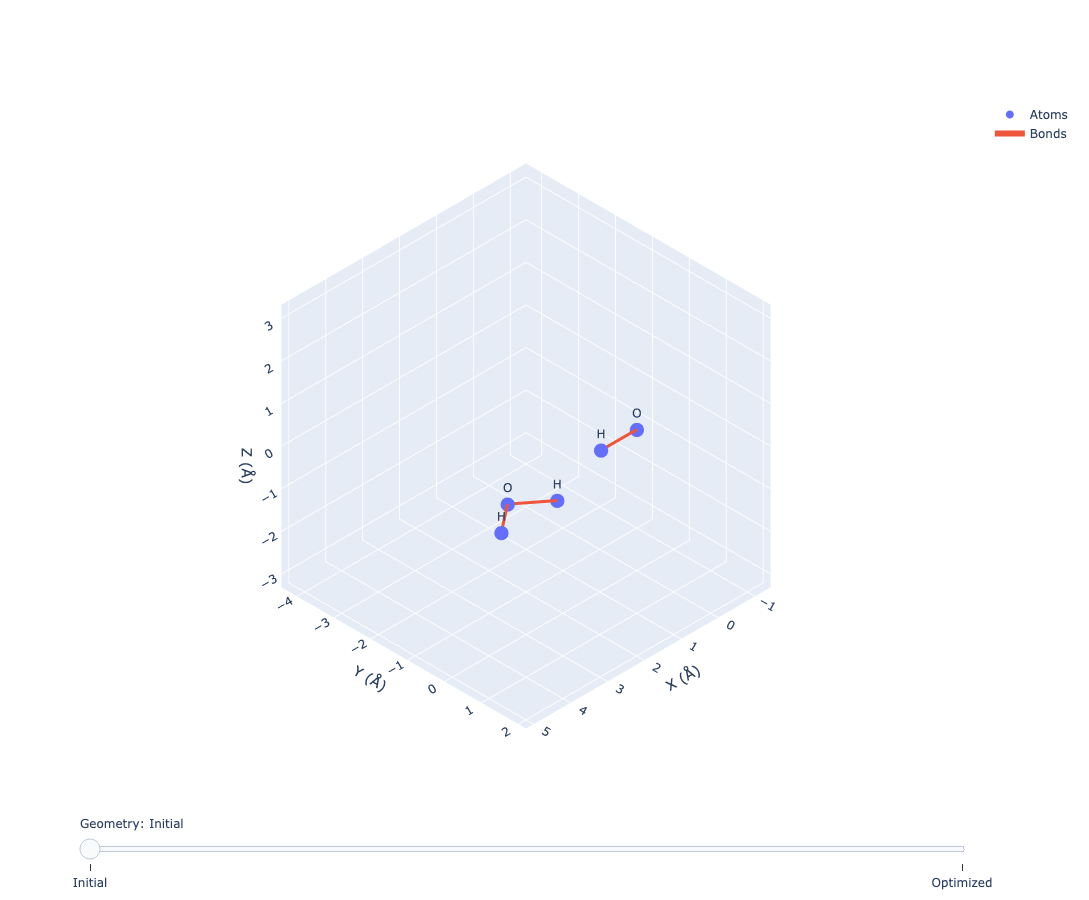

In [9]:
# Save to pick up later by ChimeraX
optimization_file = "optimization.xyz"
Hh.savexyz(
    optimization_file,
    x0_xyz,
    mol,
    result,
    water_H1_ref,
    water_H2_ref,
    water_M_ref
)
# Display right now
u = mda.Universe(optimization_file, format="XYZ")
print("Number of frames:", len(u.trajectory))
Hh.visualize_H2O_hydroxide(u)

In [10]:
Hh.finite_difference_gradient_check(result,mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params)
O_opt, H1_opt, H2_opt, M_opt = Hh.energy_breakdown_at_optimized_geometry(result,mol,energy_qm_kjmol,qm_coords,qm_atom_types,lj_params)

# ------------------------------------------------------------
# Initial QM/MM state
# ------------------------------------------------------------
O_initial, H1_initial, H2_initial, M_initial = \
    Hh.water_from_6dof(
        x0_xyz,
        water_H1_ref,
        water_H2_ref,
        water_M_ref
    )

mf_qmmm_initial, energy_initial_hartree = Hh.run_qmmm_scf(
    H1_initial,
    H2_initial,
    M_initial,
    mol
)

# ------------------------------------------------------------
# Optimized QM/MM state
# ------------------------------------------------------------

mf_qmmm_optimized, energy_optimized_hartree = Hh.run_qmmm_scf(
    H1_opt,
    H2_opt,
    M_opt,
    mol
)

# ============================================================
# Save QM states for orbital visualization
# ============================================================

# The QM molecule is the same for both frames in this calculation.
# Make separate entries so the files correspond to:
#   frame 0 = initial
#   frame 1 = optimized


optimized_molecules = [
    mol,
    mol
]

mean_field_objects = [
    mf_qmmm_initial,
    mf_qmmm_optimized
]


# ============================================================
# Save QM states for orbital visualization
# ============================================================

qm_states = []

for mf_qmmm in [mf_qmmm_initial, mf_qmmm_optimized]:

    qm_states.append({
        "mo_coeff": mf_qmmm.mo_coeff,
        "mo_energy": mf_qmmm.mo_energy,
        "mo_occ": mf_qmmm.mo_occ,
        "e_tot": mf_qmmm.e_tot
    })

QMstatefile = "qm_states.pkl"
with open(QMstatefile, "wb") as f:
    pickle.dump(qm_states, f)

waterfile = "water_optimization.pkl"
with open(waterfile, "wb") as f:
    pickle.dump(
        {
            "x_initial": x0_xyz,
            "x_optimized": result.x
        },
        f
    )
print("Saving "+QMstatefile+" and "+waterfile)
print('x0_xyz = ',x0_xyz)
print('x_optimized ',result.x)


       FINITE-DIFFERENCE GRADIENT CHECK
0:  finite difference = -0.01525627   L-BFGS-B = -0.00929390
1:  finite difference =  0.06006629   L-BFGS-B = -0.00837588
2:  finite difference = -0.00237491   L-BFGS-B = -0.00119513
3:  finite difference = -0.00423433   L-BFGS-B = -0.00582077
4:  finite difference = -0.00392376   L-BFGS-B = -0.02328306
5:  finite difference =  0.00108986   L-BFGS-B =  0.00873115
Optimized water:
O : [-4.78815479e-01 -2.49468278e+00 -2.38956722e-03]
H1: [ 0.42534891 -2.80893074  0.01102608]
H2: [-0.40117775 -1.54052503 -0.00299628]
M : [-3.52320496e-01 -2.41223706e+00 -7.39268473e-04]

Energy breakdown:
Electrostatic =  -130.793727 kJ/mol
LJ            =    26.593804 kJ/mol
Total         =  -104.199923 kJ/mol
Saving qm_states.pkl and water_optimization.pkl
x0_xyz =  [3.5 0.  0.  0.  0.  0. ]
x_optimized  [-4.78815479e-01 -2.49468278e+00 -2.38956722e-03  5.41617931e-03
 -1.39156060e-02 -9.93210433e-01]
